In [1]:
import pandas as pd
import json
import numpy as np

Scores analysis

In [16]:
num_subjects = 12
num_trials = 17
excluded_subjects = {2, 7}
scores = np.zeros((num_subjects, num_trials))

for sub_id in range(1, num_subjects + 1):
    if sub_id in excluded_subjects:
        continue
    
    df_all_trials = pd.DataFrame()
    
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)
        
        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        scores[sub_id - 1, trial_id - 1] = df["server_result.score"].iloc[-1]
        

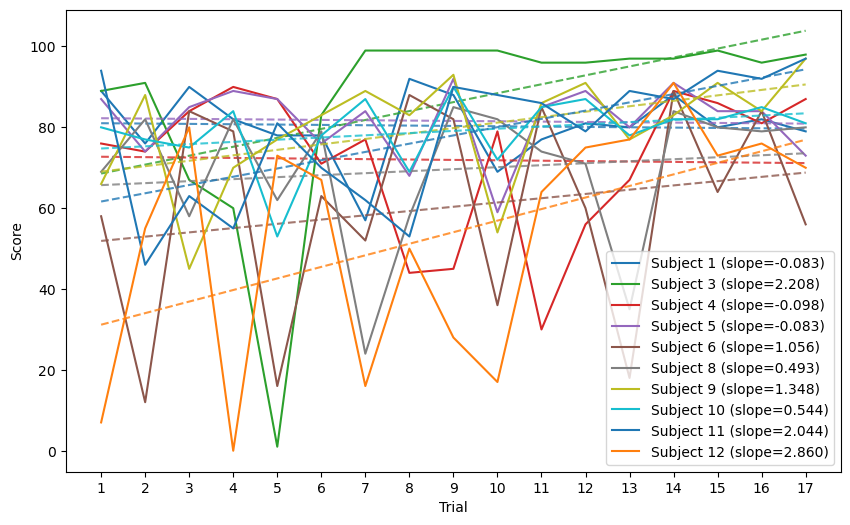

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
trial_numbers = np.arange(1, 18)

for sub_id in range(1, num_subjects + 1):
    if sub_id in excluded_subjects:
        continue

    subject_color = f'C{sub_id - 1}'
    slope, intercept = np.polyfit(trial_numbers, scores[sub_id - 1], 1)
    fitted_scores = slope * trial_numbers + intercept

    ax.plot(range(1, 18), scores[sub_id - 1], color=subject_color, label=f'Subject {sub_id} (slope={slope:.3f})')
    ax.plot(range(1, 18), fitted_scores, linestyle='--', color=subject_color, alpha=0.8)
    ax.set_xticks(range(1, 18))
    ax.set_ylabel("Score")
    ax.set_xlabel("Trial")

plt.legend()
plt.show()

Difference between desired and recommended values

In [11]:
num_subjects = 12
num_trials = 17
max_submissions = 5

# Trials with fewer than five submissions retain NaN in unused positions.
# diffs = np.full((num_subjects, num_trials, max_submissions), np.nan)
diffs = np.zeros((num_subjects, num_trials))

for sub_id in range(1, num_subjects + 1):
    for trial_id in range(1, num_trials + 1):
        with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
            data = json.load(file)

        df = pd.json_normalize(
            data,
            record_path="submissions",
            meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
        )

        slider_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_maxs"])
        ])
        rec_values_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["server_result.rec"], df["slider_maxs"])
        ])
        diff_values_frac = np.round(slider_values_frac - rec_values_frac, 2)
        # diff = np.sum(diff_values_frac, axis=1)
        diff = np.abs(diff_values_frac).sum()

        # diffs[sub_id - 1, trial_id - 1, :len(diff)] = diff
        diffs[sub_id - 1, trial_id - 1] = diff

# One row per subject; columns combine trials and submission slots.
# diffs_flat = diffs.reshape(num_subjects, -1)
# print(diffs_flat.shape)
# diffs_list = [
#     diffs_flat[i][~np.isnan(diffs_flat[i])] for i in range(num_subjects)
# ]

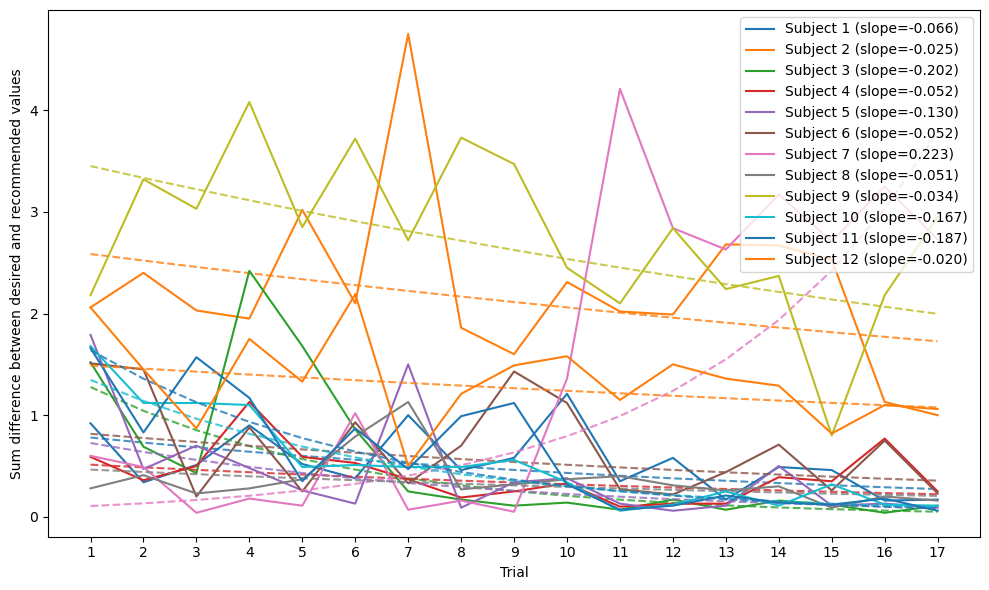

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
trial_numbers = np.arange(1, 18)

excluded_subjects = {2, 7}

for sub_id, subject_diffs in enumerate(diffs, start=1):
    # if sub_id in excluded_subjects:
    #     continue

    subject_color = f'C{sub_id - 1}'
    log_diffs = np.log(subject_diffs)
    slope, intercept = np.polyfit(trial_numbers, log_diffs, 1)
    fitted_diffs = np.exp(slope * trial_numbers + intercept)

    ax.plot(
        trial_numbers,
        subject_diffs,
        color=subject_color,
        label=f'Subject {sub_id} (slope={slope:.3f})',
    )
    ax.plot(
        trial_numbers,
        fitted_diffs,
        linestyle='--',
        color=subject_color,
        alpha=0.8,
    )

ax.set_xticks(trial_numbers)
# ax.set_ylim(-1, 2)
ax.set_xlabel('Trial')
ax.set_ylabel('Sum difference between desired and recommended values')
ax.legend()
fig.tight_layout()
plt.show()

All information displayed

In [13]:
sub_id = 3

df_all_trials = pd.DataFrame()
for trial_id in range(1, 18):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_trial_{trial_id}.json") as file:
        data = json.load(file)
    
    df = pd.json_normalize(
        data,
        record_path="submissions",
        meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
    )

    df["server_result.mrs"] = df["server_result.mrs"].shift(1) # shift mrs down by one row
    
    df_all_trials = pd.concat([df_all_trials, df])

In [15]:
df_all_trials

,submission_number,slider_values,initial_slider_values,slider_mins,slider_maxs,slider_medians,objective_names,server_result.rec,server_result.mrs,server_result.score,server_result.rec_player_indices,trial_id,submission_count,sub_id,block_id,trial_type
0,1,"[102.16, 44.98, 16.28, 1.48, 180.46]","[76.8, 38.5, 14.5, 13.9, 146.6]","[23.9, 5.1, 3.4, 0.0, 61.5]","[122.9, 85.3, 22.6, 30.9, 198.0]","[76.8, 38.5, 14.5, 13.9, 146.6]","[REB, AST, STL, BLK, PTS]","[56.6, 44.7, 15.9, 2.2, 180.0]",None,60,"[29, 56, 74, 102, 162, 165, 178, 273, 292, 325]",1,4,3,2,normal
1,2,"[89.17, 25.65, 17.32, 2.2, 180.0]","[56.6, 44.7, 15.9, 2.2, 180.0]","[23.9, 5.1, 3.4, 0.0, 61.5]","[122.9, 85.3, 22.6, 30.9, 198.0]","[76.8, 38.5, 14.5, 13.9, 146.6]","[REB, AST, STL, BLK, PTS]","[65.1, 27.7, 15.4, 3.3, 179.8]","[[0.0, -1.2301251259759762, -0.804377903983042...",14,"[29, 56, 74, 76, 162, 178, 188, 301, 315, 325]",1,4,3,2,normal
2,3,"[55.18, 60.76, 3.76, 19.0, 183.62]","[65.1, 27.7, 15.4, 3.3, 179.8]","[23.9, 5.1, 3.4, 0.0, 61.5]","[122.9, 85.3, 22.6, 30.9, 198.0]","[76.8, 38.5, 14.5, 13.9, 146.6]","[REB, AST, STL, BLK, PTS]","[54.6, 47.8, 8.6, 10.5, 169.9]","[[0.0, -1.531728146506044, -1.5121622675303126...",5,"[37, 54, 66, 78, 178, 182, 206, 225, 263, 337]",1,4,3,2,normal
3,4,"[43.91, 51.95, 18.1, 0.88, 185.2]","[54.6, 47.8, 8.6, 10.5, 169.9]","[23.9, 5.1, 3.4, 0.0, 61.5]","[122.9, 85.3, 22.6, 30.9, 198.0]","[76.8, 38.5, 14.5, 13.9, 146.6]","[REB, AST, STL, BLK, PTS]","[44.0, 52.2, 17.6, 1.6, 180.9]","[[0.0, -0.1558216611543954, 0.1208972462715068...",89,"[8, 29, 102, 165, 178, 240, 273, 292, 315, 325]",1,4,3,2,normal
0,1,"[80.15, 10.05, 19.83, 0.75, 173.03]","[79.7, 37.3, 15.0, 14.2, 144.6]","[23.8, 5.0, 3.7, 0.0, 60.1]","[118.7, 90.0, 24.1, 33.0, 205.8]","[79.7, 37.3, 15.0, 14.2, 144.6]","[REB, AST, STL, BLK, PTS]","[78.8, 26.7, 17.2, 4.6, 171.1]",None,45,"[20, 64, 133, 134, 138, 157, 166, 183, 218, 313]",2,3,3,2,normal
1,2,"[59.28, 54.98, 19.79, 4.6, 178.93]","[78.8, 26.7, 17.2, 4.6, 171.1]","[23.8, 5.0, 3.7, 0.0, 60.1]","[118.7, 90.0, 24.1, 33.0, 205.8]","[79.7, 37.3, 15.0, 14.2, 144.6]","[REB, AST, STL, BLK, PTS]","[58.6, 50.0, 19.0, 4.6, 172.4]","[[0.0, -0.19327122051989767, -1.57207477749965...",91,"[20, 64, 81, 103, 133, 166, 205, 207, 285, 312]",2,3,3,2,normal
2,3,"[58.6, 53.34, 20.18, 4.6, 181.18]","[58.6, 50.0, 19.0, 4.6, 172.4]","[23.8, 5.0, 3.7, 0.0, 60.1]","[118.7, 90.0, 24.1, 33.0, 205.8]","[79.7, 37.3, 15.0, 14.2, 144.6]","[REB, AST, STL, BLK, PTS]","[58.6, 50.0, 19.0, 4.6, 172.4]","[[0.0, -0.6283689267688578, -0.466936828347458...",91,"[20, 64, 81, 103, 133, 166, 205, 207, 285, 312]",2,3,3,2,normal
0,1,"[103.5, 26.92, 17.78, 5.95, 176.85]","[77.5, 41.4, 14.3, 11.9, 147.4]","[23.1, 5.2, 3.2, 0.0, 53.7]","[131.7, 86.9, 22.2, 28.1, 204.7]","[77.5, 41.4, 14.3, 11.9, 147.4]","[REB, AST, STL, BLK, PTS]","[80.1, 26.7, 16.2, 6.0, 176.5]",None,51,"[37, 38, 55, 134, 165, 209, 219, 232, 240, 317]",3,3,3,2,normal
1,2,"[51.34, 63.8, 16.2, 1.45, 176.5]","[80.1, 26.7, 16.2, 6.0, 176.5]","[23.1, 5.2, 3.2, 0.0, 53.7]","[131.7, 86.9, 22.2, 28.1, 204.7]","[77.5, 41.4, 14.3, 11.9, 147.4]","[REB, AST, STL, BLK, PTS]","[48.5, 63.4, 14.7, 1.9, 175.7]","[[0.0, -1.4450604351925056, -0.852781754756044...",54,"[17, 37, 75, 101, 140, 209, 267, 290, 291, 347]",3,3,3,2,normal
2,3,"[39.61, 63.4, 16.31, 1.9, 182.1]","[48.5, 63.4, 14.7, 1.9, 175.7]","[23.1, 5.2, 3.2, 0.0, 53.7]","[131.7, 86.9, 22.2, 28.1, 204.7]","[77.5, 41.4, 14.3, 11.9, 147.4]","[REB, AST, STL, BLK, PTS]","[39.7, 62.0, 15.3, 2.0, 182.1]","[[0.0, -1.043201996318639, -1.2087153010506761...",67,"[17, 55, 75, 140, 156, 209, 219, 259, 290, 291]",3,3,3,2,normal


In [14]:
info = pd.DataFrame({
    "trial_id": df_all_trials["trial_id"],
    "submission_number": df_all_trials["submission_number"],
    "initial_slider_values": df_all_trials["initial_slider_values"],
    "slider_values": df_all_trials["slider_values"]
})
mrs = [
    np.round(np.asarray(values), 2)
    if values is not None
    else np.array([])
    for values in df_all_trials["server_result.mrs"]
]
# mrs_flat = [
#     np.round(np.asarray(values), 2).ravel()
#     if values is not None
#     else np.array([])
#     for values in df_all_trials["server_result.mrs"]
# ]
initial_slider_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["initial_slider_values"], df_all_trials["slider_maxs"])
]
slider_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["slider_values"], df_all_trials["slider_maxs"])
]
rec_values_frac = [
    np.asarray(values) / np.asarray(maxs)
    for values, maxs in zip(df_all_trials["server_result.rec"], df_all_trials["slider_maxs"])
]
slider_value_changes_frac = [
    np.round(slider_value - initial_slider_value, 2)
    for slider_value, initial_slider_value in zip(slider_values_frac, initial_slider_values_frac)
]
diff_values_frac = [
    np.round(slider_value - rec_value, 2)
    for slider_value, rec_value in zip(slider_values_frac, rec_values_frac)
]
# positive diff means not reachable objective values
# negative diff means too conservative

info["slider_value_changes_frac"] = slider_value_changes_frac
info["diff_values_frac"] = diff_values_frac
info["mrs"] = mrs
info["score"] = df_all_trials["server_result.score"]
info.to_csv(f"sub_{sub_id}_info.csv", index=False)
info.head()

,trial_id,submission_number,initial_slider_values,slider_values,slider_value_changes_frac,diff_values_frac,mrs,score
0,1,1,"[76.8, 38.5, 14.5, 13.9, 146.6]","[102.16, 44.98, 16.28, 1.48, 180.46]","[0.21, 0.08, 0.08, -0.4, 0.17]","[0.37, 0.0, 0.02, -0.02, 0.0]",[],60
1,1,2,"[56.6, 44.7, 15.9, 2.2, 180.0]","[89.17, 25.65, 17.32, 2.2, 180.0]","[0.27, -0.22, 0.06, 0.0, 0.0]","[0.2, -0.02, 0.08, -0.04, 0.0]","[[0.0, -1.23, -0.8, -0.07, -1.3], [-0.35, 0.0,...",14
2,1,3,"[65.1, 27.7, 15.4, 3.3, 179.8]","[55.18, 60.76, 3.76, 19.0, 183.62]","[-0.08, 0.39, -0.52, 0.51, 0.02]","[0.0, 0.15, -0.21, 0.28, 0.07]","[[0.0, -1.53, -1.51, 1.24, -0.98], [-0.13, 0.0...",5
3,1,4,"[54.6, 47.8, 8.6, 10.5, 169.9]","[43.91, 51.95, 18.1, 0.88, 185.2]","[-0.09, 0.05, 0.42, -0.31, 0.08]","[-0.0, -0.0, 0.02, -0.02, 0.02]","[[0.0, -0.16, 0.12, -0.08, 0.0], [-2.0, 0.0, 0...",89
0,2,1,"[79.7, 37.3, 15.0, 14.2, 144.6]","[80.15, 10.05, 19.83, 0.75, 173.03]","[0.0, -0.3, 0.2, -0.41, 0.14]","[0.01, -0.18, 0.11, -0.12, 0.01]",[],45


In [78]:
with pd.option_context(
    "display.max_colwidth", None,
    "display.max_rows", None,
):
    display(info[["slider_value_changes_frac", "mrs"]])

,slider_value_changes_frac,mrs
0,"[0.21, 0.08, 0.08, -0.4, 0.17]",[]
1,"[0.27, -0.22, 0.06, 0.0, 0.0]","[[0.0, -1.23, -0.8, -0.07, -1.3], [-0.35, 0.0, 0.14, -0.62, -0.71], [-0.02, 0.45, 0.0, 0.14, -0.38], [-0.14, -1.32, 0.79, 0.0, -0.41], [-0.23, -0.39, -0.47, -0.44, 0.0]]"
2,"[-0.08, 0.39, -0.52, 0.51, 0.02]","[[0.0, -1.53, -1.51, 1.24, -0.98], [-0.13, 0.0, -0.26, -0.07, -0.18], [-0.65, -0.62, 0.0, 0.47, -0.67], [0.15, -0.31, 0.18, 0.0, 0.01], [-0.9, -1.39, -1.5, 0.57, 0.0]]"
3,"[-0.09, 0.05, 0.42, -0.31, 0.08]","[[0.0, -0.16, 0.12, -0.08, 0.0], [-2.0, 0.0, 0.41, -1.4, -1.19], [0.3, 0.22, 0.0, 0.17, 0.22], [-1.16, -0.85, 0.26, 0.0, -1.11], [-1.05, -0.8, 0.37, -1.01, 0.0]]"
0,"[0.0, -0.3, 0.2, -0.41, 0.14]",[]
1,"[-0.16, 0.31, 0.11, 0.0, 0.04]","[[0.0, -0.19, -1.57, 0.14, -1.67], [0.52, 0.0, 0.56, -0.11, -0.34], [-1.12, 0.55, 0.0, -0.01, -1.31], [0.69, -0.73, 1.2, 0.0, -0.23], [-1.1, 0.14, -1.48, 0.06, 0.0]]"
2,"[0.0, 0.04, 0.05, 0.0, 0.04]","[[0.0, -0.63, -0.47, -0.68, -0.38], [-0.33, 0.0, -0.43, -0.9, -0.61], [-0.3, -0.62, 0.0, -0.59, -0.5], [0.08, -0.24, -0.11, 0.0, -0.24], [-0.18, -0.64, -0.47, -0.41, 0.0]]"
0,"[0.2, -0.17, 0.16, -0.21, 0.14]",[]
1,"[-0.22, 0.43, 0.0, -0.16, 0.0]","[[0.0, -1.45, -0.85, 0.52, -0.75], [-0.34, 0.0, -0.27, -0.11, -0.45], [-0.83, -0.39, 0.0, 0.27, -0.56], [-0.0, -0.04, 0.01, 0.0, -0.24], [-0.97, -1.24, -0.9, -0.09, 0.0]]"
2,"[-0.07, 0.0, 0.07, 0.0, 0.03]","[[0.0, -1.04, -1.21, 0.01, -0.95], [-0.67, 0.0, -1.41, -0.06, -1.1], [-0.2, -0.45, 0.0, 0.24, -0.48], [0.42, 0.51, 0.59, 0.0, 0.62], [-0.38, -0.64, -0.92, 0.27, 0.0]]"


Regression between mrs and slider value change

In [68]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

valid_rows = info["mrs"].notna() & info["slider_value_changes_frac"].notna()
model_data = info.loc[valid_rows].copy()

mrs_matrices = np.stack(model_data["mrs"].map(lambda value: np.asarray(value, dtype=float)))
y = np.stack(
    model_data["slider_value_changes_frac"].map(lambda value: np.asarray(value, dtype=float))
)

n_objectives = mrs_matrices.shape[1]
off_diagonal = ~np.eye(n_objectives, dtype=bool)
X = mrs_matrices[:, off_diagonal]
feature_names = [
    f"mrs_{i}_{j}"
    for i in range(n_objectives)
    for j in range(n_objectives)
    if i != j
]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

metrics = pd.DataFrame({
    "objective": np.arange(n_objectives),
    "r2": r2_score(y_test, y_pred, multioutput="raw_values"),
    "mae": mean_absolute_error(y_test, y_pred, multioutput="raw_values"),
})
print(f"Train observations: {len(X_train)}, test observations: {len(X_test)}")
display(metrics)

Train observations: 16, test observations: 4


,objective,r2,mae
0,0,-2.362086,0.248795
1,1,-8.722599,0.634669
2,2,0.015291,0.215075
3,3,-3.407425,0.369529
4,4,-1.702012,0.039355


In [ ]:
# per objective regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

valid_rows = info["mrs"].notna() & info["slider_value_changes_frac"].notna()
model_data = info.loc[valid_rows].copy()

mrs_matrices = np.stack(model_data["mrs"].map(lambda value: np.asarray(value, dtype=float)))
y = np.stack(
    model_data["slider_value_changes_frac"].map(lambda value: np.asarray(value, dtype=float))
)

n_objectives = mrs_matrices.shape[1]
off_diagonal = ~np.eye(n_objectives, dtype=bool)
X = mrs_matrices[:, off_diagonal]

In [ ]:
metrics = []

for i in range(n_objectives):
    X_i = X[:, i*4:(i+1)*4]
    y_i = y[:, i]
    X_train, X_test, y_train, y_test = train_test_split(X_i, y_i, test_size=0.1, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics.append({
        "objective": i,
        "r2": r2_score(y_test, y_pred),
        "mae": mean_absolute_error(y_test, y_pred),
    })

metrics = pd.DataFrame(metrics)
display(metrics)

Tradeoff knowledge analysis

In [6]:
from itertools import combinations

corrs_by_year = {}
for year in range(2000, 2017):
    items_df = pd.read_csv(f"data/items/items_{year}.csv").drop(columns=["PLAYER", "SALARY"])
    objective_names = items_df.columns.to_numpy()
    corrs = items_df.corr().to_numpy()
    
    pair_corrs = {
        (objective_names[i], objective_names[j]): corrs[i, j]
        for i, j in combinations(range(len(objective_names)), 2)
    }
    corrs_by_year[year] = dict(
        sorted(pair_corrs.items(), key=lambda pair: pair[1], reverse=True)
    )

In [8]:
num_subjects = 10
objective_order = {name: i for i, name in enumerate(objective_names)}

def tradeoff_key(values):
    return tuple(sorted(values, key=objective_order.get))

for sub_id in range(1, num_subjects + 1):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_query.json") as file:
            data = json.load(file)
        
    df = pd.json_normalize(data)
    small_tradeoff = df["largest_tradeoff_1"][0]
    large_tradeoff = df["largest_tradeoff_2"][0]
    small_tradeoff_key = tradeoff_key(small_tradeoff)
    large_tradeoff_key = tradeoff_key(large_tradeoff)

    print(sub_id, small_tradeoff_key, large_tradeoff_key)

    
    small_rank = []
    large_rank = []
    for year in range(2000, 2017):
        keys = list(corrs_by_year[year].keys())
        small_index = keys.index(small_tradeoff_key)
        large_index = keys.index(large_tradeoff_key)

        small_rank.append(small_index)
        large_rank.append(large_index)

        avg_small_rank = np.asarray(small_rank).mean()
        avg_large_rank = np.asarray(large_rank).mean()

    print(int(avg_small_rank))
    print(int(avg_large_rank))
    print("--------------------------------")


1 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------
2 ('STL', 'PTS') ('AST', 'BLK')
3
8
--------------------------------
3 ('AST', 'STL') ('REB', 'AST')
1
9
--------------------------------
4 ('BLK', 'PTS') ('REB', 'AST')
5
9
--------------------------------
5 ('STL', 'PTS') ('AST', 'BLK')
3
8
--------------------------------
6 ('BLK', 'PTS') ('REB', 'AST')
5
9
--------------------------------
7 ('REB', 'BLK') ('AST', 'BLK')
0
8
--------------------------------
8 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------
9 ('AST', 'PTS') ('AST', 'BLK')
2
8
--------------------------------
10 ('STL', 'PTS') ('REB', 'AST')
3
9
--------------------------------


/tmp/ipykernel_712300/2911026258.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


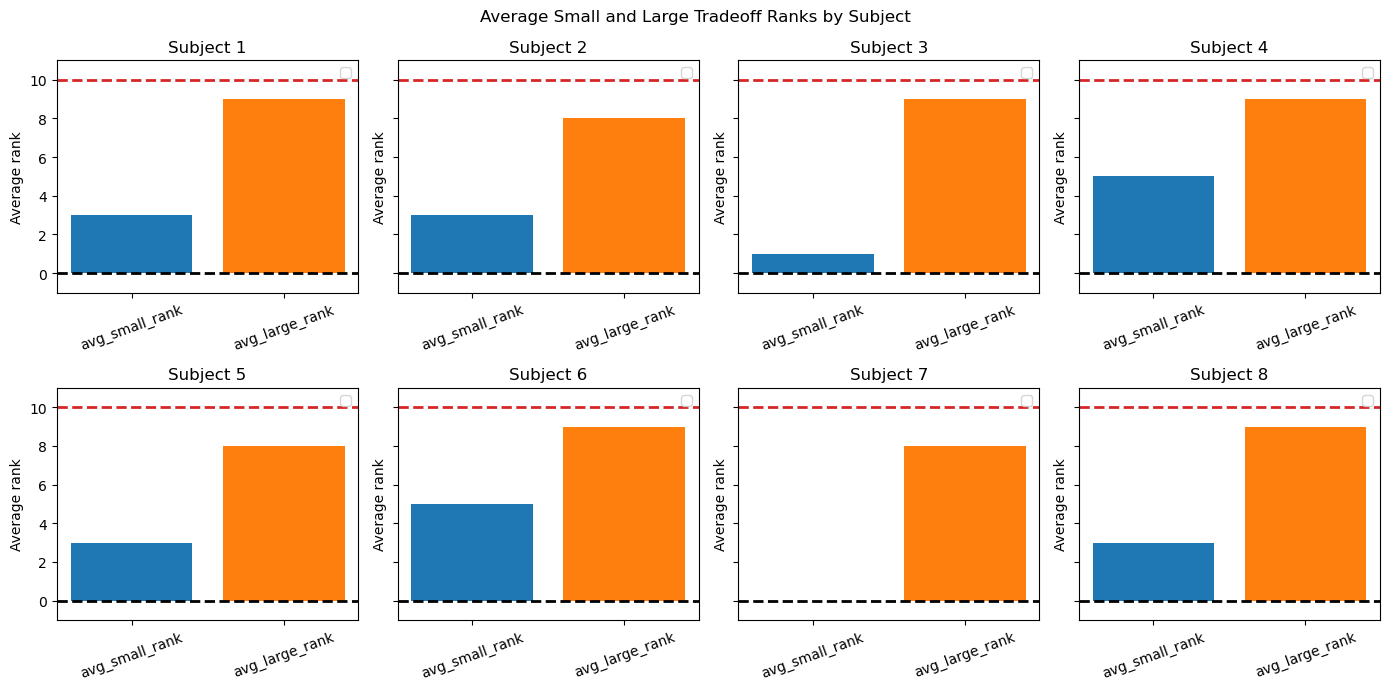

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(14, 7), sharey=True)
axes = axes.ravel()

for sub_id, ax in zip(range(1, num_subjects + 1), axes):
    with open(f"data/sub_data/sub_{sub_id}/sub_{sub_id}_block_2_query.json") as file:
        data = json.load(file)

    df = pd.json_normalize(data)
    small_tradeoff_key = tradeoff_key(df["largest_tradeoff_1"][0])
    large_tradeoff_key = tradeoff_key(df["largest_tradeoff_2"][0])

    small_ranks = []
    large_ranks = []
    for year in range(2000, 2017):
        ranked_tradeoffs = list(corrs_by_year[year].keys())
        small_ranks.append(ranked_tradeoffs.index(small_tradeoff_key))
        large_ranks.append(ranked_tradeoffs.index(large_tradeoff_key))

    avg_small_rank = np.mean(small_ranks)
    avg_large_rank = np.mean(large_ranks)
    ax.bar(
        ["avg_small_rank", "avg_large_rank"],
        [avg_small_rank, avg_large_rank],
        color=["tab:blue", "tab:orange"],
    )
    ax.set_title(f"Subject {sub_id}")
    ax.tick_params(axis="x", labelrotation=20)
    ax.set_ylabel("Average rank")
    ax.set_ylim(-1, 11)
    ax.axhline(y=0, color='black', linestyle='--', linewidth=2)
    ax.axhline(y=10, color='C3', linestyle='--', linewidth=2)
    ax.legend()

fig.suptitle("Average Small and Large Tradeoff Ranks by Subject")
fig.tight_layout()
plt.show()

In [6]:
STAT_ORDER = ["REB", "AST", "STL", "BLK", "PTS"]
STRATEGY_TYPES = [
    "REB+AST+STL", "REB+AST+BLK", "REB+AST+PTS", "REB+STL+BLK",
    "REB+STL+PTS", "REB+BLK+PTS", "AST+STL+BLK", "AST+STL+PTS",
    "AST+BLK+PTS", "STL+BLK+PTS",
]
STRATEGY_SETS = {s: set(s.split("+")) for s in STRATEGY_TYPES}

if "subject_mapping" not in globals():
    all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv")
    subject_mapping = (
        all_info_nonshifted[["sub_id", "original_sub_id"]]
        .drop_duplicates()
        .sort_values("sub_id")
    )


def match_strategies(preferred):
    """Map a subject's preferred stats onto the size-3 strategy types.

    Exact 3-stat lists become one label, in STAT_ORDER.
    Longer lists match every size-3 coalition contained in the preferred set.
    Shorter lists match every coalition that contains the preferred set.
    """
    preferred = [s for s in preferred if s in STAT_ORDER]
    pref = set(preferred)
    if len(pref) == 3:
        label = "+".join(s for s in STAT_ORDER if s in pref)
        return [label] if label in STRATEGY_SETS else []
    contained = [s for s in STRATEGY_TYPES if STRATEGY_SETS[s] <= pref]
    if contained:
        return contained
    return [s for s in STRATEGY_TYPES if pref <= STRATEGY_SETS[s]]


rows = []
for row in subject_mapping.itertuples(index=False):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)
    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_pre_query.json") as file:
        data = json.load(file)
    preferred = list(data["preferred_statistics"])
    matched = match_strategies(preferred)
    rows.append({
        "sub_id": sub_id,
        "original_sub_id": original_sub_id,
        "preferred_statistics": preferred,
        "n_preferred": len(preferred),
        "matched_strategies": matched,
        "n_matched": len(matched),
        "exact_match": "+".join(s for s in STAT_ORDER if s in preferred) if len(set(preferred)) == 3 else None,
    })

pref_strategy = pd.DataFrame(rows)
pref_strategy

,sub_id,original_sub_id,preferred_statistics,n_preferred,matched_strategies,n_matched,exact_match
0,0,2,"[STL, BLK, PTS, AST, REB]",5,"[REB+AST+STL, REB+AST+BLK, REB+AST+PTS, REB+ST...",10,None
1,1,3,"[REB, AST, PTS, STL]",4,"[REB+AST+STL, REB+AST+PTS, REB+STL+PTS, AST+ST...",4,None
2,2,4,"[AST, PTS, BLK]",3,[AST+BLK+PTS],1,AST+BLK+PTS
3,3,5,"[REB, AST, STL]",3,[REB+AST+STL],1,REB+AST+STL
4,4,6,"[AST, STL, BLK]",3,[AST+STL+BLK],1,AST+STL+BLK
5,5,8,"[PTS, REB, AST]",3,[REB+AST+PTS],1,REB+AST+PTS
6,6,9,"[AST, BLK, PTS]",3,[AST+BLK+PTS],1,AST+BLK+PTS
7,7,10,"[PTS, AST, REB]",3,[REB+AST+PTS],1,REB+AST+PTS
8,8,11,"[REB, AST, BLK]",3,[REB+AST+BLK],1,REB+AST+BLK
9,9,12,"[BLK, AST, REB]",3,[REB+AST+BLK],1,REB+AST+BLK


In [1]:
import pandas as pd
import json
import numpy as np

In [3]:
num_subjects = 10
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv")

subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)
print(subject_mapping)

     sub_id  original_sub_id
0         0                2
84        1                3
121       2                4
173       3                5
236       4                6
300       5                8
369       6                9
447       7               10
517       8               11
572       9               12


In [10]:
for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_query.json") as file:
            data = json.load(file)

    df = pd.json_normalize(data)
    print("sub_id", sub_id)
    print(df["preference_shifted"])
    print(df["preference_text"])
    print("--------------------------------")


sub_id 0
0    True
Name: preference_shifted, dtype: bool
0    I did not focus on a specific stats.
Name: preference_text, dtype: object
--------------------------------
sub_id 1
0    True
Name: preference_shifted, dtype: bool
0    I continued to dump block but also began to du...
Name: preference_text, dtype: object
--------------------------------
sub_id 2
0    True
Name: preference_shifted, dtype: bool
0    i shifted to prefer stl and blk and pts
Name: preference_text, dtype: object
--------------------------------
sub_id 3
0    False
Name: preference_shifted, dtype: bool
0    Steals and Points
Name: preference_text, dtype: object
--------------------------------
sub_id 4
0    True
Name: preference_shifted, dtype: bool
0    Based on relative tradeoff strength. I put mor...
Name: preference_text, dtype: object
--------------------------------
sub_id 5
0    True
Name: preference_shifted, dtype: bool
0    I don't predefine which three statistics I wan...
Name: preference_text, dtype: ob

In [24]:
num_trials = 17
original_sub_id = 5

rows = []
for trial_id in range(1, num_trials + 1):
    # trial_rows = all_info_nonshifted.loc[
    #     (all_info_nonshifted["sub_id"] == sub_id)
    #     & (all_info_nonshifted["trial_id"] == trial_id)
    # ]

    # last_submission = int(trial_rows["submission_number"].max())
    # aspiration = np.asarray(
    #         trial_rows.loc[
    #             trial_rows["submission_number"] == last_submission,
    #             "slider_values",
    #         ].iloc[0],
    #         dtype=float,
    #     )
    # aspirations[trial_id - 1] = aspiration

    with open(f"data/sub_data/sub_{original_sub_id}/sub_{original_sub_id}_block_2_trial_{trial_id}.json") as file:
        data = json.load(file)

    df = pd.json_normalize(
        data,
        record_path="submissions",
        meta=["trial_id", "submission_count", "sub_id", "block_id", "trial_type"],
    )

    aspiration_frac = np.asarray([
            np.asarray(values) / np.asarray(maxs)
            for values, maxs in zip(df["slider_values"], df["slider_medians"])
        ])[-1]
    rows.append(aspiration_frac)

objective_names = df["objective_names"].iloc[-1]
aspiration_fracs = pd.DataFrame(rows, columns=objective_names)


In [25]:
aspiration_fracs

,REB,AST,STL,BLK,PTS
0,0.664062,1.216623,1.393103,0.676259,1.292087
1,1.025094,0.812332,1.222000,0.950704,1.081950
2,1.056774,0.673913,1.188811,1.100840,1.121438
3,1.031123,0.728191,1.153285,1.375940,1.049078
4,1.173333,0.840855,1.079268,1.166667,1.106796
5,1.072997,0.650000,1.057237,1.156716,1.092354
6,1.062642,1.020930,0.987952,1.191892,1.164236
7,1.002621,0.784406,1.050000,1.122137,1.163624
8,0.888771,0.954660,1.134615,1.241935,1.095615
9,0.932040,0.846231,1.136054,0.927536,1.182930


Pareto front sizes:

In [5]:
import ast
from pathlib import Path
from mrs import density_filter
import pandas as pd
import numpy as np

num_subjects = 10
num_trials = 17
all_info_nonshifted = pd.read_csv("data/all_info_10_nonshifted.csv")
subject_mapping = (
    all_info_nonshifted[["sub_id", "original_sub_id"]]
    .drop_duplicates()
    .sort_values("sub_id")
)
print(subject_mapping)

     sub_id  original_sub_id
0         0                2
84        1                3
121       2                4
173       3                5
236       4                6
300       5                8
369       6                9
447       7               10
517       8               11
572       9               12


In [13]:
size_ratios_all_subjects = np.zeros((num_subjects, num_trials))
for i, row in enumerate(subject_mapping.itertuples(index=False)):
    sub_id = int(row.sub_id)
    original_sub_id = int(row.original_sub_id)

    size_ratios = np.zeros(num_trials)
    for trial_id in range(1, num_trials + 1):
        trial_rows = all_info_nonshifted.loc[
            (all_info_nonshifted["sub_id"] == sub_id)
            & (all_info_nonshifted["trial_id"] == trial_id)
        ]
        if trial_rows.empty:
            continue

        last_submission = int(trial_rows["submission_number"].max())
        unbiased_files = list(
            Path("data/game_data").glob(
                f"pf_block_2_trial_{trial_id}_*.csv"
            )
        )
        if len(unbiased_files) != 1:
            raise ValueError(
                f"Trial {trial_id}: expected one unbiased PF, "
                f"found {len(unbiased_files)}"
            )
        unbiased_pf = pd.read_csv(unbiased_files[0]).to_numpy()
        unbiased_pf, _ = density_filter(unbiased_pf, 0.8)

        biased_path = Path(
            f"data/results/sub_{original_sub_id}/block_2/"
            f"trial_{trial_id}/submission_{last_submission}/pf.csv"
        )
        biased_pf = pd.read_csv(biased_path).to_numpy()

        size_ratio = biased_pf.shape[0] / unbiased_pf.shape[0]
        size_ratios[trial_id - 1] = size_ratio

    size_ratios_all_subjects[sub_id] = size_ratios

print(size_ratios_all_subjects.shape)

(10, 17)


In [15]:
size_ratios_all_subjects.mean()

0.44355915177090066